# TF-IDF vs DistilBERT Crossover on Small Text Data

This notebook is a lightly-restructured, cell-by-cell version of the original `method.py` script.

**What the original experiment does:** it compares a classical TF-IDF + logistic-regression text classifier against a CPU-fine-tuned DistilBERT model on short-text sentiment classification (Rotten Tomatoes / SST-2), sweeping the training-set size `n` over `{50, 200, 500, 1000}` with 2 seeds per `(domain, n)`. It then asks whether a **label-free** signal — the Good-Turing/Chao1 estimate of *unseen n-gram vocabulary mass* on a small unlabeled pilot sample — can predict the `n` at which DistilBERT overtakes TF-IDF (the "crossover point"), and whether that predictor transfers across domains.

**Result in the full run:** DistilBERT was ahead of TF-IDF+LR at *every* tested `n` on both domains, so there was no finite empirical crossover to predict against — the overall verdict recorded was `DISCONFIRMED`, but the full pipeline (both classifiers, the coverage-curve machinery, and the cross-domain calibration logic) is intact and runnable end-to-end.

**This demo** runs the exact same code path on a tiny curated subset of Rotten Tomatoes (bundled as `mini_demo_data.json`, ~100 examples) with minimal config (few `n` values, 1 seed, 1 fine-tuning epoch) so it finishes in a couple of minutes instead of tens of minutes on the full sweep."

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, psutil, accelerate -- NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')
_pip('psutil==7.1.0')
_pip('accelerate==1.11.0')

# numpy, scipy, scikit-learn, torch, transformers, pandas -- pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'matplotlib==3.10.0', 'torch==2.9.0', 'transformers==5.0.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports and hardware setup

Copied from the top of `method.py` almost as-is: environment variables for HF caching, thread counts, logging setup, and the container-aware CPU/RAM detection used to size a `RLIMIT_AS` guard.

In [2]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import resource
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
from loguru import logger
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt  # for the results visualization cell at the end

WORKDIR = Path.cwd()
os.environ.setdefault("HF_HOME", str(WORKDIR / ".hf_cache"))
os.environ.setdefault("HF_DATASETS_CACHE", str(WORKDIR / ".hf_cache" / "datasets"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(WORKDIR / ".hf_cache" / "transformers"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "4")

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WORKDIR / "logs").mkdir(exist_ok=True)
logger.add(WORKDIR / "logs" / "run.log", rotation="30 MB", level="DEBUG")

# ------------------------------------------------------------------ hardware
def _detect_cpus() -> int:
    try:
        parts = Path("/sys/fs/cgroup/cpu.max").read_text().split()
        if parts[0] != "max":
            return math.ceil(int(parts[0]) / int(parts[1]))
    except (FileNotFoundError, ValueError):
        pass
    try:
        return len(os.sched_getaffinity(0))
    except (AttributeError, OSError):
        return os.cpu_count() or 1


def _container_ram_gb() -> float:
    for p in ["/sys/fs/cgroup/memory.max", "/sys/fs/cgroup/memory/memory.limit_in_bytes"]:
        try:
            v = Path(p).read_text().strip()
            if v != "max" and int(v) < 1_000_000_000_000:
                return int(v) / 1e9
        except (FileNotFoundError, ValueError):
            pass
    return psutil.virtual_memory().total / 1e9


NUM_CPUS = _detect_cpus()
TOTAL_RAM_GB = _container_ram_gb()
RAM_BUDGET_BYTES = int(min(TOTAL_RAM_GB * 0.6, 16.0) * 1e9)
resource.setrlimit(resource.RLIMIT_AS, (RAM_BUDGET_BYTES * 3, RAM_BUDGET_BYTES * 3))
logger.info(f"NUM_CPUS={NUM_CPUS} TOTAL_RAM_GB={TOTAL_RAM_GB:.1f} RAM_BUDGET_GB={RAM_BUDGET_BYTES/1e9:.1f}")

import torch  # noqa: E402  (import after thread-count env vars are set)

torch.set_num_threads(max(1, NUM_CPUS))
from transformers import (  # noqa: E402
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast,
    Trainer,
    TrainingArguments,
)

22:04:52|INFO   |NUM_CPUS=2 TOTAL_RAM_GB=16.0 RAM_BUDGET_GB=9.6


## Load the demo data

The original script calls `datasets.load_dataset(...)` to pull the full Rotten Tomatoes / SST-2 / IMDB corpora. For this demo we bundle a small, already-downloaded, curated subset of Rotten Tomatoes (`mini_demo_data.json`, ~100 examples split into a labeled pool, an unlabeled pool, and a held-out test set) so the notebook doesn't need to fetch and process full datasets. It's loaded from GitHub with a local-file fallback so the notebook works both standalone and on Colab.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-d8fc3d-vocabulary-saturation-predicts-the/main/round-1/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("domains in demo data:", list(data.keys()))
for dom, d in data.items():
    print(f"  {dom}: labeled={len(d['labeled_texts'])} unlabeled={len(d['unlabeled_pool'])} test={len(d['test_texts'])}")

domains in demo data: ['rotten_tomatoes']
  rotten_tomatoes: labeled=60 unlabeled=20 test=20


## Config

All tunable parameters from `method.py`, gathered in one place. Values here are set to the **minimum** that still produces a meaningful curve (few `n` values, 1 seed, 1 fine-tuning epoch, small bootstrap count) so the whole notebook finishes in a couple of minutes on CPU. The commented-out values are the **original full-scale** settings (`NS_FULL`, `SEEDS_FULL`, etc.) -- restore them (and use the full dataset instead of the mini demo one) for a full reproduction.

In [5]:
# --------------------------------------------------------------- DEMO config (minimal, fast)
SEEDS_FULL = [0]                 # original: [0, 1]
NS_FULL = [20, 50]               # original: [50, 200, 500, 1000] (bounded by our 60-example labeled pool)
DOMAINS_ORDER = ["rotten_tomatoes"]  # original: ["rotten_tomatoes", "sst2", "imdb"]
PILOT_NS = [20]                  # original: [100, 200, 400]
VOCAB_METHODS = ["mi"]           # original: ["mi", "freq"]
TEST_N = 20                      # original: 800 (fixed held-out size per domain)
UNLABELED_POOL_N = 20            # original: 6000
LABELED_POOL_CAP = 60            # original: 4000
MAX_LEN = 64                     # unchanged
N_BOOTSTRAP = 5                  # original: 15 (bootstrap resamples per coverage-curve point)
TIME_BUDGET_S = 8 * 60.0         # original: 35 * 60.0 (wall-clock budget for the DistilBERT sweep)

_EPOCH_TIERS = {20: 1, 50: 1, 200: 4, 500: 3, 1000: 3, 1500: 2, 2000: 2}  # original: {50: 5, 200: 4, 500: 3, 1000: 3, 1500: 2, 2000: 2}

PART_A_START = time.time()
CHECKPOINT_PATH = WORKDIR / "results" / "part_a_checkpoint.json"
degradation_log: list[str] = []


def ci95(vals) -> float:
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) < 2:
        return 0.0
    return 1.96 * vals.std(ddof=1) / math.sqrt(len(vals))

## Data loading and sampling helpers

`_balanced_sample` and `stratified_sample` are copied unchanged from `method.py`. `load_domains` is adapted: instead of calling `datasets.load_dataset(...)` for each domain, it builds the same `domains` dict structure directly from the pre-split `data` we just loaded (which already has `labeled_texts`/`labeled_labels`, `unlabeled_pool`, `test_texts`/`test_labels` per domain, so the test/labeled/unlabeled splitting logic from the original `build()` closure is not needed here -- that split was done once when the mini demo file was curated).

In [6]:
# ------------------------------------------------------------------ data loading (unchanged from method.py)
def _balanced_sample(texts, labels, n, seed, exclude_idx=None):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    idx_all = np.arange(len(texts))
    if exclude_idx is not None:
        mask = np.ones(len(texts), dtype=bool)
        mask[list(exclude_idx)] = False
        idx_all = idx_all[mask]
    classes = np.unique(labels[idx_all])
    per_class = n // len(classes)
    chosen = []
    for c in classes:
        pool = idx_all[labels[idx_all] == c]
        rng.shuffle(pool)
        take = min(per_class, len(pool))
        chosen.extend(pool[:take].tolist())
    rng.shuffle(chosen)
    chosen = chosen[:n]
    return chosen


# ------------------------------------------------------------------ load_domains: adapted to read from `data` (the mini demo JSON) instead of datasets.load_dataset(...)
def load_domains() -> dict:
    domains = {}
    for name in DOMAINS_ORDER:
        if name not in data:
            logger.warning(f"domain {name} not present in demo data; skipping")
            continue
        d = data[name]
        labeled_texts = d["labeled_texts"][:LABELED_POOL_CAP]
        labeled_labels = d["labeled_labels"][:LABELED_POOL_CAP]
        unlabeled_pool = d["unlabeled_pool"][:UNLABELED_POOL_N]
        test_texts = d["test_texts"][:TEST_N]
        test_labels = d["test_labels"][:TEST_N]
        n_pos = sum(test_labels)
        logger.info(
            f"domain={name} labeled_pool={len(labeled_texts)} unlabeled_pool={len(unlabeled_pool)} "
            f"test={len(test_texts)} (pos={n_pos}/{len(test_labels)})"
        )
        assert len(set(test_labels)) >= 2, f"{name}: test split missing a class"
        domains[name] = dict(
            labeled_pool=(labeled_texts, labeled_labels),
            unlabeled_pool=unlabeled_pool,
            test_texts=test_texts,
            test_labels=test_labels,
        )
    return domains


def stratified_sample(texts, labels, n, seed):
    idx = _balanced_sample(texts, labels, n, seed)
    return [texts[i] for i in idx], [labels[i] for i in idx]

## Part A: the two classifiers

`train_tfidf_lr` fits TF-IDF (unigrams+bigrams) + logistic regression and returns test accuracy. `finetune_distilbert` fine-tunes `distilbert-base-uncased` for a small number of epochs (looked up from `_EPOCH_TIERS` by training-set size `n`) using HuggingFace's `Trainer`, then evaluates test accuracy. Both are copied unchanged from `method.py`.

In [7]:
# ------------------------------------------------------------------ Part A: classifiers (unchanged from method.py)
def train_tfidf_lr(train_texts, train_labels, test_texts, test_labels, seed):
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)
    Xtr = vec.fit_transform(train_texts)
    Xte = vec.transform(test_texts)
    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=seed, class_weight="balanced")
    clf.fit(Xtr, train_labels)
    return float(clf.score(Xte, test_labels))


class SimpleTorchDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


_TOKENIZER = None


def finetune_distilbert(train_texts, train_labels, test_texts, test_labels, seed, n):
    global _TOKENIZER
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    if _TOKENIZER is None:
        _TOKENIZER = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
    tok = _TOKENIZER
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

    train_enc = tok(train_texts, truncation=True, padding=True, max_length=MAX_LEN)
    test_enc = tok(test_texts, truncation=True, padding=True, max_length=MAX_LEN)
    train_ds = SimpleTorchDataset(train_enc, train_labels)
    test_ds = SimpleTorchDataset(test_enc, test_labels)

    epochs = _EPOCH_TIERS.get(n, 2)
    out_dir = WORKDIR / "hf_runs" / f"db_{seed}_{n}_{int(time.time()*1000)}"
    args = TrainingArguments(
        output_dir=str(out_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        learning_rate=5e-5,
        weight_decay=0.01,
        logging_steps=200,
        use_cpu=True,
        seed=seed,
        report_to=[],
        save_strategy="no",
        eval_strategy="no",
        disable_tqdm=True,
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds)
    t0 = time.time()
    trainer.train()
    train_secs = time.time() - t0
    preds = trainer.predict(test_ds).predictions.argmax(-1)
    acc = float((preds == np.array(test_labels)).mean())

    del model, trainer, train_enc, test_enc, train_ds, test_ds
    gc.collect()
    import shutil

    shutil.rmtree(out_dir, ignore_errors=True)
    return acc, train_secs


def empirical_crossover(curve_domain: pd.DataFrame):
    """Smallest n where mean_db - mean_tfidf flips sign from <=0 to >0 (linear interp)."""
    cd = curve_domain.sort_values("n").reset_index(drop=True)
    gaps = cd["gap"].values
    ns = cd["n"].values
    if len(ns) == 0:
        return None, "no_data"
    if (gaps > 0).all():
        return None, "distilbert_ahead_at_all_tested_n"
    if (gaps <= 0).all():
        return None, "distilbert_never_ahead_in_tested_range"
    for i in range(1, len(ns)):
        if gaps[i - 1] <= 0 and gaps[i] > 0:
            if gaps[i] == gaps[i - 1]:
                n_star = float(ns[i])
            else:
                frac = (0 - gaps[i - 1]) / (gaps[i] - gaps[i - 1])
                n_star = float(ns[i - 1] + frac * (ns[i] - ns[i - 1]))
            return n_star, "interpolated"
    return None, "no_clean_crossing"

## Part B: label-free coverage curves

The label-free predictor: pick a small "pilot" labeled sample, extract the most discriminative n-grams (by mutual information or raw frequency), then measure on growing unlabeled samples how much of that vocabulary's probability mass is *still unseen* (Good-Turing) and how species-rich it is (Chao1). All copied unchanged from `method.py`.

In [8]:
# ------------------------------------------------------------------ Part B: coverage (unchanged from method.py, except n_bootstrap now reads N_BOOTSTRAP)
def discriminative_ngrams(pilot_texts, pilot_labels, method="mi", top_k=2000):
    cv = CountVectorizer(ngram_range=(1, 2), min_df=2, binary=True)
    X = cv.fit_transform(pilot_texts)
    if X.shape[1] == 0:
        cv = CountVectorizer(ngram_range=(1, 1), min_df=1, binary=True)
        X = cv.fit_transform(pilot_texts)
    if method == "mi":
        scores = mutual_info_classif(X, pilot_labels, discrete_features=True, random_state=0)
    else:
        scores = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(cv.get_feature_names_out())
    top_idx = np.argsort(scores)[::-1][: min(top_k, len(vocab))]
    return set(vocab[top_idx].tolist())


def _count_ngram_occurrences(docs, target_ngram_set, ngram_range=(1, 2)):
    cv = CountVectorizer(ngram_range=ngram_range, vocabulary=sorted(target_ngram_set))
    X = cv.transform(docs)
    totals = np.asarray(X.sum(axis=0)).ravel()
    vocab = cv.get_feature_names_out()
    return dict(zip(vocab, totals.tolist()))


def good_turing_unseen_mass(subsample_docs, target_ngram_set, ngram_range=(1, 2)):
    counts = _count_ngram_occurrences(subsample_docs, target_ngram_set, ngram_range)
    N = sum(counts.values())
    f1 = sum(1 for c in counts.values() if c == 1)
    p0_hat = f1 / N if N > 0 else 1.0
    seen_frac = (len([g for g, c in counts.items() if c > 0]) / len(target_ngram_set)) if target_ngram_set else 0.0
    return p0_hat, seen_frac


def chao1_richness(subsample_docs, target_ngram_set, ngram_range=(1, 2)):
    counts = _count_ngram_occurrences(subsample_docs, target_ngram_set, ngram_range)
    f1 = sum(1 for c in counts.values() if c == 1)
    f2 = sum(1 for c in counts.values() if c == 2)
    s_obs = sum(1 for c in counts.values() if c > 0)
    s_chao1 = s_obs + (f1**2) / (2 * max(f2, 1))
    return float(s_chao1), int(s_obs)


def coverage_curve(domain_data, pilot_n, method, n_points, n_bootstrap=N_BOOTSTRAP):
    labeled_texts, labeled_labels = domain_data["labeled_pool"]
    pilot_texts, pilot_labels = stratified_sample(labeled_texts, labeled_labels, min(pilot_n, len(labeled_texts)), seed=0)
    disc_vocab = discriminative_ngrams(pilot_texts, pilot_labels, method=method)
    unlabeled_pool = domain_data["unlabeled_pool"]
    rows = []
    for n in n_points:
        if n > len(unlabeled_pool):
            n_eff = len(unlabeled_pool)
        else:
            n_eff = n
        boot_vals = []
        for b in range(n_bootstrap):
            rng = np.random.default_rng(b)
            sub_idx = rng.choice(len(unlabeled_pool), size=n_eff, replace=(n_eff > len(unlabeled_pool)))
            sub = [unlabeled_pool[i] for i in sub_idx]
            _, seen_frac = good_turing_unseen_mass(sub, disc_vocab)
            boot_vals.append(1 - seen_frac)
        rows.append(dict(n=n, unseen_mean=float(np.mean(boot_vals)), unseen_ci=float(ci95(boot_vals))))
    return pd.DataFrame(rows), disc_vocab


def interp_crossing(ns, unseen_means, tau):
    """First n where unseen_mean <= tau (linear interp); None if tau outside observed range."""
    ns = np.asarray(ns, dtype=float)
    um = np.asarray(unseen_means, dtype=float)
    order = np.argsort(ns)
    ns, um = ns[order], um[order]
    if tau > um[0] or tau < um[-1] - 1e-9:
        if tau > um[0]:
            return None  # tau above the curve's starting unseen-mass: undefined (edge artifact)
    for i in range(len(ns)):
        if um[i] <= tau:
            if i == 0:
                return float(ns[0])
            n0, n1 = ns[i - 1], ns[i]
            u0, u1 = um[i - 1], um[i]
            if u0 == u1:
                return float(n1)
            frac = (u0 - tau) / (u0 - u1)
            return float(n0 + frac * (n1 - n0))
    return None  # tau never reached within observed range


def calibrate_and_predict(cov_curve_A, true_nstar_A, cov_curve_B):
    tau = float(np.interp(true_nstar_A, cov_curve_A["n"], cov_curve_A["unseen_mean"]))
    n_hat_B = interp_crossing(cov_curve_B["n"].values, cov_curve_B["unseen_mean"].values, tau)
    return n_hat_B, tau


def compute_overall_verdict(predictions, correlations):
    valid_preds = [p for p in predictions if p["within_2x"] is not None]
    if not valid_preds:
        return "DISCONFIRMED"
    hit_rate = sum(1 for p in valid_preds if p["within_2x"]) / len(valid_preds)
    sig_corrs = [c for c in correlations.values() if c["pval"] is not None and c["pval"] < 0.10 and c["rho"] < 0]
    if hit_rate >= 0.5 and len(sig_corrs) >= max(1, len(correlations) // 2):
        return "SUPPORTED"
    if hit_rate > 0 or len(sig_corrs) > 0:
        return "PARTIAL"
    return "DISCONFIRMED"

## Run: load domains, then the Part A sweep

This mirrors the top of `main()` in `method.py`: load the domains, run a quick smoke test (1 epoch DistilBERT fine-tune + a coverage-curve monotonicity check), then run the full `(domain, n, seed)` sweep with checkpointing (so a crash never loses completed runs) and a wall-clock guard that skips remaining combos if the time budget is exceeded.

In [9]:
logger.info("=" * 70)
logger.info("Loading domains")
domains = load_domains()
domain_names = [d for d in DOMAINS_ORDER if d in domains]
logger.info(f"Domains loaded: {domain_names}")

# -------- smoke test (1 seed, epochs=1) on first domain --------
smoke_domain = domains[domain_names[0]]
smoke_n = NS_FULL[0]
tr_t, tr_l = stratified_sample(*smoke_domain["labeled_pool"], smoke_n, seed=0)
acc_lr_smoke = train_tfidf_lr(tr_t, tr_l, smoke_domain["test_texts"], smoke_domain["test_labels"], seed=0)
assert 0.0 <= acc_lr_smoke <= 1.0
t0 = time.time()
acc_db_smoke, secs_smoke = finetune_distilbert(
    tr_t, tr_l, smoke_domain["test_texts"], smoke_domain["test_labels"], seed=0, n=smoke_n
)
assert 0.0 <= acc_db_smoke <= 1.0
per_epoch_secs = secs_smoke  # 1 epoch at n=smoke_n
logger.info(f"SMOKE OK: acc_tfidf={acc_lr_smoke:.3f} acc_db={acc_db_smoke:.3f} 1-epoch-n{smoke_n}-secs={secs_smoke:.1f}")

# coverage-curve smoke check: seen_frac should rise monotonically-ish with n
pilot_t, pilot_l = stratified_sample(*smoke_domain["labeled_pool"], min(PILOT_NS[0], len(smoke_domain["labeled_pool"][0])), seed=0)
vocab_smoke = discriminative_ngrams(pilot_t, pilot_l, method="mi")
seen_fracs = []
for n_chk in NS_FULL:
    n_eff = min(n_chk, len(smoke_domain["unlabeled_pool"]))
    sub = smoke_domain["unlabeled_pool"][:n_eff]
    p0, sf = good_turing_unseen_mass(sub, vocab_smoke)
    assert 0.0 <= p0 <= 1.0 and 0.0 <= sf <= 1.0
    seen_fracs.append(sf)
logger.info(f"SMOKE coverage seen_fracs at n={NS_FULL}: {seen_fracs}")
if not all(seen_fracs[i] <= seen_fracs[i + 1] + 1e-6 for i in range(len(seen_fracs) - 1)):
    degradation_log.append(f"coverage-curve smoke check non-monotonic: {seen_fracs}")
    logger.warning(f"seen_frac not monotonic: {seen_fracs}")

# -------- timing-based budget projection --------
def est_run_secs(n):
    epochs = _EPOCH_TIERS.get(n, 2)
    return per_epoch_secs * epochs * max(1.0, n / smoke_n) * 0.6  # 0.6 damping: larger batches amortize overhead

seeds, ns = list(SEEDS_FULL), list(NS_FULL)
total_est = sum(est_run_secs(n) for n in ns for _ in seeds for _ in domain_names)
logger.info(f"Projected Part-A DistilBERT total: {total_est/60:.1f} min (budget {TIME_BUDGET_S/60:.0f} min)")

22:06:30|INFO   |======================================================================


22:06:30|INFO   |Loading domains


22:06:30|INFO   |domain=rotten_tomatoes labeled_pool=60 unlabeled_pool=20 test=20 (pos=10/20)


22:06:30|INFO   |Domains loaded: ['rotten_tomatoes']


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '5.788', 'train_samples_per_second': '3.455', 'train_steps_per_second': '0.346', 'train_loss': '0.721', 'epoch': '1'}


22:06:39|INFO   |SMOKE OK: acc_tfidf=0.700 acc_db=0.500 1-epoch-n20-secs=6.0


22:06:39|INFO   |SMOKE coverage seen_fracs at n=[20, 50]: [0.58, 0.58]


22:06:39|INFO   |Projected Part-A DistilBERT total: 0.2 min (budget 8 min)


In [10]:
# -------- Part A: full sweep with running wall-clock guard + checkpointing --------
results = []
done_combos = set()
if CHECKPOINT_PATH.exists():
    try:
        ckpt = json.loads(CHECKPOINT_PATH.read_text())
        results = ckpt.get("results", [])
        done_combos = {(r["domain"], r["n"], r["seed"]) for r in results}
        logger.info(f"Resumed checkpoint: {len(results)} runs already completed, skipping them")
    except (json.JSONDecodeError, KeyError, OSError) as e:
        logger.warning(f"Could not load checkpoint ({e}); starting fresh")

def _save_checkpoint():
    CHECKPOINT_PATH.parent.mkdir(exist_ok=True)
    CHECKPOINT_PATH.write_text(json.dumps({"results": results}, default=str))

part_a_t0 = time.time()
skipped = []
combos = [(d, n, s) for d in domain_names for n in ns for s in seeds]
n_done = len(results)
for domain, n, seed in combos:
    if (domain, n, seed) in done_combos:
        continue
    elapsed = time.time() - part_a_t0
    remaining = len(combos) - n_done
    avg = (elapsed / max(1, n_done - len(done_combos))) if n_done > len(done_combos) else est_run_secs(n)
    if elapsed + avg * remaining > TIME_BUDGET_S and n_done > 0:
        skipped.append((domain, n, seed))
        continue
    d = domains[domain]
    train_texts, train_labels = stratified_sample(*d["labeled_pool"], n, seed)
    acc_lr = train_tfidf_lr(train_texts, train_labels, d["test_texts"], d["test_labels"], seed)
    acc_db, secs = finetune_distilbert(train_texts, train_labels, d["test_texts"], d["test_labels"], seed, n)
    results.append(
        dict(domain=domain, n=n, seed=seed, acc_tfidf=acc_lr, acc_distilbert=acc_db, db_train_secs=secs)
    )
    n_done += 1
    _save_checkpoint()
    logger.info(
        f"[{n_done}/{len(combos)}] domain={domain} n={n} seed={seed} "
        f"acc_tfidf={acc_lr:.3f} acc_db={acc_db:.3f} secs={secs:.1f} elapsed={elapsed/60:.1f}min"
    )
if skipped:
    degradation_log.append(f"skipped {len(skipped)} runs mid-sweep due to running time budget: {skipped[:10]}...")
    logger.warning(f"Skipped {len(skipped)} combos due to time budget")

df = pd.DataFrame(results)
assert len(df) > 0, "no Part-A results produced"

curve_rows = []
for (domain, n), g in df.groupby(["domain", "n"]):
    curve_rows.append(
        dict(
            domain=domain,
            n=n,
            mean_tfidf=g["acc_tfidf"].mean(),
            ci_tfidf=ci95(g["acc_tfidf"]),
            mean_db=g["acc_distilbert"].mean(),
            ci_db=ci95(g["acc_distilbert"]),
            n_seeds=len(g),
        )
    )
curve = pd.DataFrame(curve_rows)
curve["gap"] = curve["mean_db"] - curve["mean_tfidf"]

true_crossovers = {}
for domain in domain_names:
    cd = curve[curve.domain == domain]
    if len(cd) < 2:
        true_crossovers[domain] = dict(n_star=None, direction="insufficient_n_points")
        continue
    n_star, direction = empirical_crossover(cd)
    true_crossovers[domain] = dict(n_star=n_star, direction=direction)
logger.info(f"True crossovers: {true_crossovers}")

# sanity check: TF-IDF accuracy should be non-decreasing (within noise) in n for >=2/3 domains
monotonic_ok = 0
for domain in domain_names:
    cd = curve[curve.domain == domain].sort_values("n")
    diffs = np.diff(cd["mean_tfidf"].values)
    if (diffs >= -0.05).sum() >= max(1, len(diffs) - 1):
        monotonic_ok += 1
if monotonic_ok < max(1, math.ceil(len(domain_names) * 2 / 3)):
    degradation_log.append(
        f"TF-IDF accuracy non-monotonic in n for {len(domain_names)-monotonic_ok}/{len(domain_names)} domains "
        "(possible leakage/sampling issue) — reported as-is per fallback plan"
    )
    logger.warning("TF-IDF monotonicity sanity check failed for some domains")

curve

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '2.423', 'train_samples_per_second': '8.254', 'train_steps_per_second': '0.825', 'train_loss': '0.721', 'epoch': '1'}


22:06:43|INFO   |[1/2] domain=rotten_tomatoes n=20 seed=0 acc_tfidf=0.700 acc_db=0.500 secs=2.6 elapsed=0.0min


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

{'train_runtime': '6.401', 'train_samples_per_second': '7.811', 'train_steps_per_second': '0.625', 'train_loss': '0.6867', 'epoch': '1'}


22:06:51|INFO   |[2/2] domain=rotten_tomatoes n=50 seed=0 acc_tfidf=0.300 acc_db=0.550 secs=6.6 elapsed=0.1min


22:06:52|INFO   |True crossovers: {'rotten_tomatoes': {'n_star': 33.33333333333333, 'direction': 'interpolated'}}


22:06:52|WARNING|TF-IDF monotonicity sanity check failed for some domains


,domain,n,mean_tfidf,ci_tfidf,mean_db,ci_db,n_seeds,gap
0,rotten_tomatoes,20,0.7,0.0,0.50,0.0,1,-0.20
1,rotten_tomatoes,50,0.3,0.0,0.55,0.0,1,0.25


## Run: coverage curves, cross-domain predictions, correlations, verdict

This is the rest of `main()`: compute coverage curves for every `(domain, pilot_n, method)` combo (Part B), calibrate the Good-Turing threshold on one domain and try to predict the crossover on another (Part C -- with a single domain in this demo there are no cross-domain pairs, matching how the original handled a domain with no finite crossover), the pilot-size/vocab-method ablation, the gap-vs-unseen-mass Spearman correlation (Part D), and the overall verdict.

In [11]:
# -------- Part B: coverage curves (label-free) --------
logger.info("Computing coverage curves (Part B)")
coverage_curves = {}
for domain in domain_names:
    for pilot_n in PILOT_NS:
        for method in VOCAB_METHODS:
            cov_df, vocab = coverage_curve(domains[domain], pilot_n, method, n_points=ns)
            coverage_curves[(domain, pilot_n, method)] = cov_df
            logger.debug(f"coverage_curve domain={domain} pilot_n={pilot_n} method={method} vocab_size={len(vocab)}")

# -------- Part C: cross-domain calibrate/predict --------
logger.info("Computing cross-domain predictions (Part C)")
predictions = []
for A in domain_names:
    for B in domain_names:
        if A == B:
            continue
        nstar_A = true_crossovers[A]["n_star"]
        if nstar_A is None:
            predictions.append(
                dict(calibrate_on=A, predict_on=B, n_hat_star=None, n_true_star=true_crossovers[B]["n_star"],
                     within_2x=None, tau=None, note=f"skipped: {A} has no finite empirical crossover")
            )
            continue
        cov_A = coverage_curves[(A, PILOT_NS[0], "mi")]
        cov_B = coverage_curves[(B, PILOT_NS[0], "mi")]
        n_hat_B, tau = calibrate_and_predict(cov_A, nstar_A, cov_B)
        n_true_B = true_crossovers[B]["n_star"]
        ratio = (n_hat_B / n_true_B) if (n_true_B and n_hat_B) else None
        predictions.append(
            dict(
                calibrate_on=A,
                predict_on=B,
                n_hat_star=n_hat_B,
                n_true_star=n_true_B,
                within_2x=(ratio is not None and 0.5 <= ratio <= 2.0),
                tau=tau,
                note=None,
            )
        )
logger.info(f"Cross-domain predictions: {predictions}")

# -------- pilot-size / MI-vs-freq ablation summary --------
ablation_rows = []
for domain in domain_names:
    nstar = true_crossovers[domain]["n_star"]
    for pilot_n in PILOT_NS:
        for method in VOCAB_METHODS:
            cov = coverage_curves[(domain, pilot_n, method)]
            if nstar is not None:
                tau_self = float(np.interp(nstar, cov["n"], cov["unseen_mean"]))
            else:
                tau_self = None
            ablation_rows.append(dict(domain=domain, pilot_n=pilot_n, method=method, tau_self=tau_self))

# -------- Part D: correlation --------
logger.info("Computing gap-vs-unseen-mass correlations (Part D)")
correlations = {}
for domain in domain_names:
    gap_series = curve[curve.domain == domain].sort_values("n")["gap"].values
    cov = coverage_curves[(domain, PILOT_NS[0], "mi")].sort_values("n")
    unseen_series = cov["unseen_mean"].values
    if len(gap_series) >= 3 and len(unseen_series) == len(gap_series):
        rho, pval = spearmanr(unseen_series, gap_series)
        correlations[domain] = dict(rho=float(rho), pval=float(pval), n_points=len(gap_series))
    else:
        correlations[domain] = dict(rho=None, pval=None, n_points=len(gap_series))
logger.info(f"Correlations: {correlations}")

verdict = compute_overall_verdict(predictions, correlations)
logger.info(f"OVERALL VERDICT: {verdict}")

22:06:52|INFO   |Computing coverage curves (Part B)


22:06:52|INFO   |Computing cross-domain predictions (Part C)


22:06:52|INFO   |Cross-domain predictions: []


22:06:52|INFO   |Computing gap-vs-unseen-mass correlations (Part D)


22:06:52|INFO   |Correlations: {'rotten_tomatoes': {'rho': None, 'pval': None, 'n_points': 2}}


22:06:52|INFO   |OVERALL VERDICT: DISCONFIRMED


## Results

A readable summary table plus a plot of TF-IDF vs DistilBERT accuracy against training-set size `n`, and the coverage curve(s) used by the label-free predictor.

OVERALL VERDICT: DISCONFIRMED

Accuracy curve (mean over seeds, 95% CI):
         domain  n  mean_tfidf  ci_tfidf  mean_db  ci_db  n_seeds   gap
rotten_tomatoes 20         0.7       0.0     0.50    0.0        1 -0.20
rotten_tomatoes 50         0.3       0.0     0.55    0.0        1  0.25

True empirical crossovers (n where DistilBERT overtakes TF-IDF+LR):
  rotten_tomatoes: n_star=33.33333333333333 (interpolated)

Gap-vs-unseen-mass correlations:
  rotten_tomatoes: rho=None pval=None (n_points=2)

Degradations applied:
  - TF-IDF accuracy non-monotonic in n for 1/1 domains (possible leakage/sampling issue) — reported as-is per fallback plan


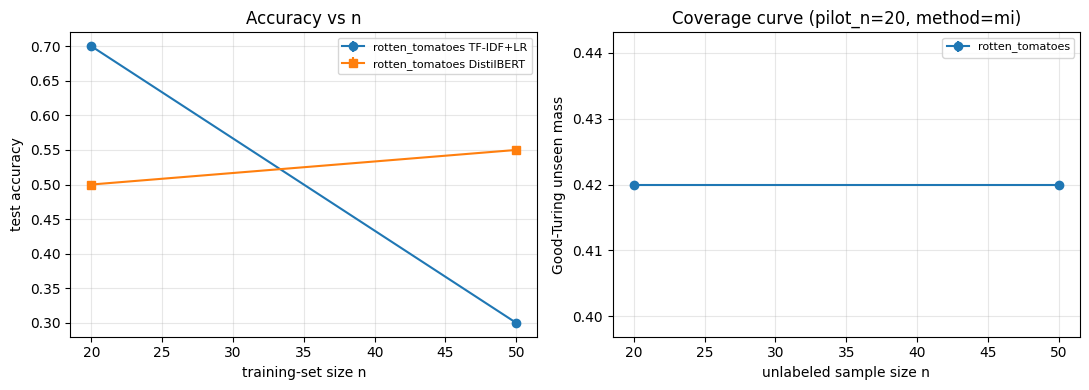

In [12]:
print(f"OVERALL VERDICT: {verdict}\n")

print("Accuracy curve (mean over seeds, 95% CI):")
print(curve.to_string(index=False))

print("\nTrue empirical crossovers (n where DistilBERT overtakes TF-IDF+LR):")
for domain, tc in true_crossovers.items():
    print(f"  {domain}: n_star={tc['n_star']} ({tc['direction']})")

print("\nGap-vs-unseen-mass correlations:")
for domain, c in correlations.items():
    print(f"  {domain}: rho={c['rho']} pval={c['pval']} (n_points={c['n_points']})")

if degradation_log:
    print("\nDegradations applied:")
    for d in degradation_log:
        print(f"  - {d}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for domain in domain_names:
    cd = curve[curve.domain == domain].sort_values("n")
    ax.errorbar(cd["n"], cd["mean_tfidf"], yerr=cd["ci_tfidf"], marker="o", label=f"{domain} TF-IDF+LR")
    ax.errorbar(cd["n"], cd["mean_db"], yerr=cd["ci_db"], marker="s", label=f"{domain} DistilBERT")
ax.set_xlabel("training-set size n")
ax.set_ylabel("test accuracy")
ax.set_title("Accuracy vs n")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for (domain, pilot_n, method), cov_df in coverage_curves.items():
    if pilot_n == PILOT_NS[0] and method == "mi":
        cd = cov_df.sort_values("n")
        ax.errorbar(cd["n"], cd["unseen_mean"], yerr=cd["unseen_ci"], marker="o", label=domain)
ax.set_xlabel("unlabeled sample size n")
ax.set_ylabel("Good-Turing unseen mass")
ax.set_title(f"Coverage curve (pilot_n={PILOT_NS[0]}, method=mi)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()